# Initialization

In [1]:
import stim
import itertools
import logging
import random
import pandas as pd
import os



from concurrent.futures import ProcessPoolExecutor

from wrappers.polar_wrapper import (
    polar_code_p2, get_logical_error_on_accepted_states, divide_half_list
)
from wrappers.stim_wrapper import (
    calculate_logical_error_result_polar,
    simulate_batch_and_save_result_polar,
    generate_qiskit_polar_code, compiled_to_qiskit_hardware,
    get_backend_information, convert_i_to_meas_type,
    generate_circuit_extraction_syndrome_stim_normal, 
    create_circuit_polar_stim_normal,
    simulate_stim_polar_code_normal,
    simulate_batch_and_save_result_polar_normal,
    calculate_logical_error_result_polar_normal,
    compile_circuit_qiskit_to_stim,
    create_circuit_polar_stim_from_qiskit,
    simulate_stim_polar_code_normal_from_qiskit_circuit
)

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import Layout
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import copy 


# Stim Simulation Normal

## Toy Example

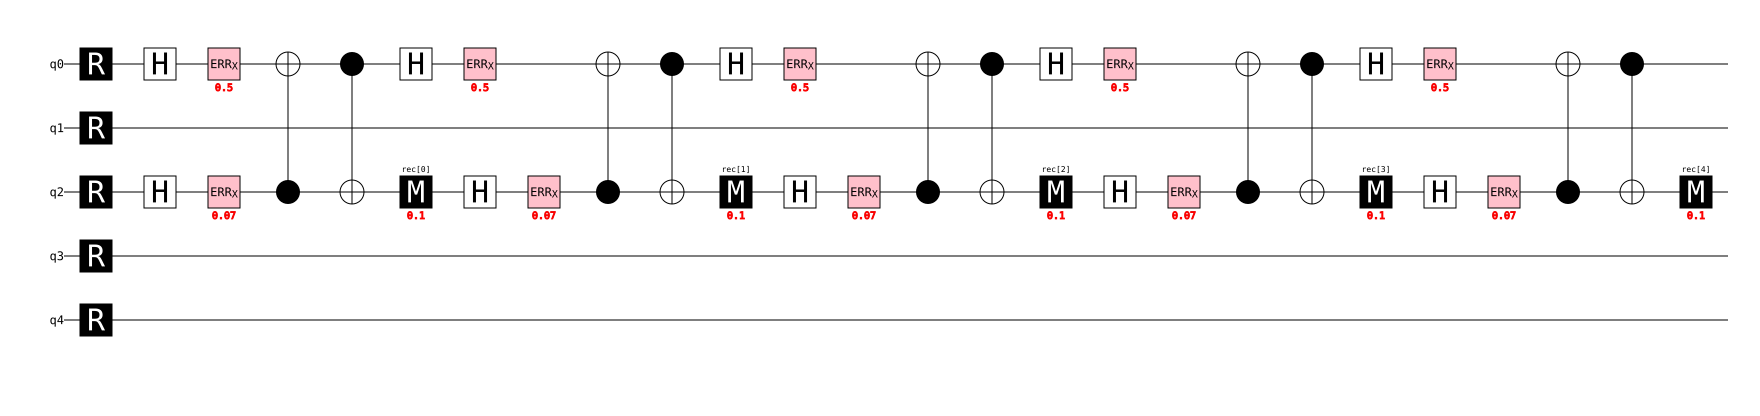

In [2]:
# manual polar_n3_x
circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
circuit.append("R", range(0,5))

for i in range(5):

    circuit.append("H", [0,2])
    circuit.append("X_ERROR", [0], [0.5] )
    circuit.append("X_ERROR", [2], [0.07] )
    # noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)
    # circuit.append("H", [5])
    circuit.append("CNOT", [2, 0])
    circuit.append("CNOT", [0, 2],)
    circuit.append("MZ", [2], 0.1)
    # circuit.append("M", [0, 2])




circuit.diagram("timeline-svg")


### Noiseless

In [3]:
# manual polar_n3_x
circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
circuit.append("R", range(0,12))

circuit.append("H", [2,5,8,11])
circuit.append("CNOT", [2, 0, 5, 3, 8, 6, 11, 9])
circuit.append("CNOT", [2, 1, 5, 4, 8, 7, 11, 10])
circuit.append("H", [2,5,8,11])
circuit.append("M", [2,5,8,11])

circuit.append("R", [2,5,8,11])
circuit.append("CNOT", [0, 2, 1, 5, 6, 8, 7, 11])
circuit.append("CNOT", [3, 2, 4, 5, 9, 8, 10, 11])
circuit.append("M", [2,5,8,11])

circuit.append("R", [2,5,8,11])
circuit.append("H", [2,5,8,11])
circuit.append("CNOT", [2, 0, 5, 1, 8, 3, 11, 4])
circuit.append("CNOT", [2, 6, 5, 7, 8, 9, 11, 10])
circuit.append("H", [2,5,8,11])
circuit.append("M", [2,5,8,11])

circuit.append("H", [0,1,3,4,6,7,9,10])
circuit.append("M", [0,1,3,4,6,7,9,10])


In [4]:
data = [2, 0, 5, 3, 8, 6, 11, 9]

# Zip the list with a slice of itself starting from the second element
for x1, x2 in zip(data[::2], data[1::2]):
    print(f"x1 = {x1}, x2 = {x2}")

x1 = 2, x2 = 0
x1 = 5, x2 = 3
x1 = 8, x2 = 6
x1 = 11, x2 = 9


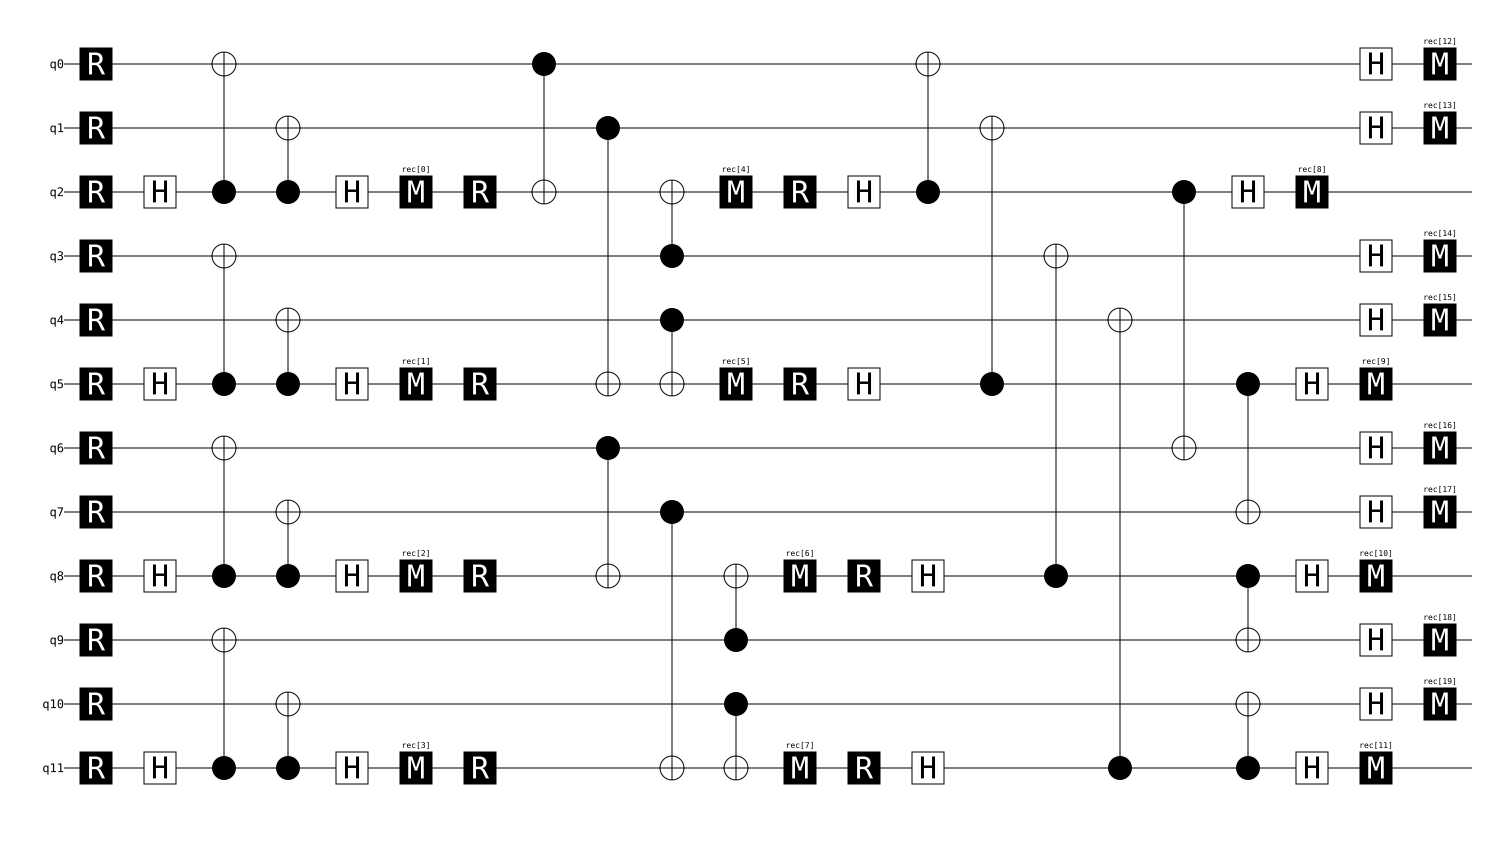

In [5]:
circuit.diagram("timeline-svg")

In [6]:
sampler = circuit.compile_sampler(seed=1)
results = sampler.sample(shots=int(1e4) )

res_bit_string = {}
for res in results:
    bit_string = ""
    for i in res:
        if i:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if bit_string in res_bit_string:
        res_bit_string[bit_string] = res_bit_string[bit_string] + 1
    else:
        res_bit_string[bit_string] = 1

n = 3
lstate = "X"
get_logical_error_on_accepted_states(n, lstate, res_bit_string)


(10000, 0, 0, 1.0, 0.5153543569977046, 0.20772356200177455)

### Noisy

In [7]:
def add_stim_error(circuit: stim.Circuit, p_error):
    noisy_circuit = stim.Circuit()

    for ins in circuit:
        used_qubits = []
        idle_qubits = []

        if ins.name != "M":
            noisy_circuit.append(ins)
        
        # TICK doesn't have an error
        if ins.name == "TICK":
            continue
        
        if ins.name == "H":
            noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)
        elif ins.name == "CX":
            noisy_circuit.append("DEPOLARIZE2", ins.targets_copy(), p_error)
        elif ins.name == "M":
            noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)
        elif ins.name == "R":
            noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)

        for qt in ins.targets_copy():
            used_qubits.append(qt.value)

        for i in range(circuit.num_qubits):
            if i not in used_qubits:
                idle_qubits.append(stim.GateTarget(i))

        if ins.name == "M":
            noisy_circuit.append(ins)
        
        if len(idle_qubits) > 1:
            noisy_circuit.append("DEPOLARIZE1", idle_qubits, p_error)    

    return noisy_circuit

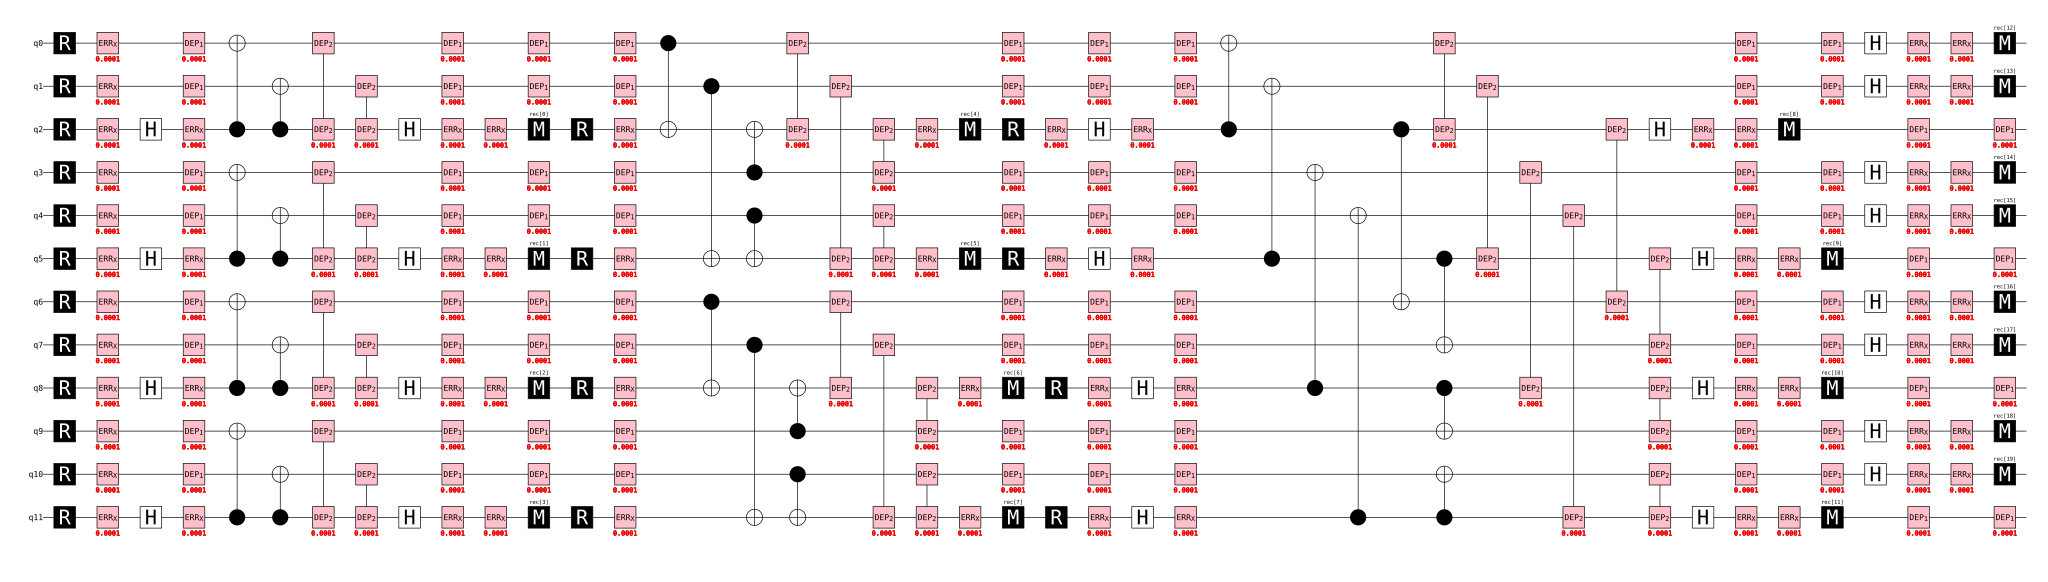

In [8]:
noisy_circuit = add_stim_error(circuit, 0.0001)
noisy_circuit.diagram("timeline-svg")


In [9]:
sampler = noisy_circuit.compile_sampler(seed=1)
results = sampler.sample(shots=int(1e4) )

res_bit_string = {}
for res in results:
    bit_string = ""
    for i in res:
        if i:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if bit_string in res_bit_string:
        res_bit_string[bit_string] = res_bit_string[bit_string] + 1
    else:
        res_bit_string[bit_string] = 1

n = 3
lstate = "X"
get_logical_error_on_accepted_states(n, lstate, res_bit_string)


(9886, 10, 21, 0.9989884685413717, 0.8020487230023718, -0.18068773700360907)

## Put into Function

In [10]:
# the code has been moved to stim_wrapper.py

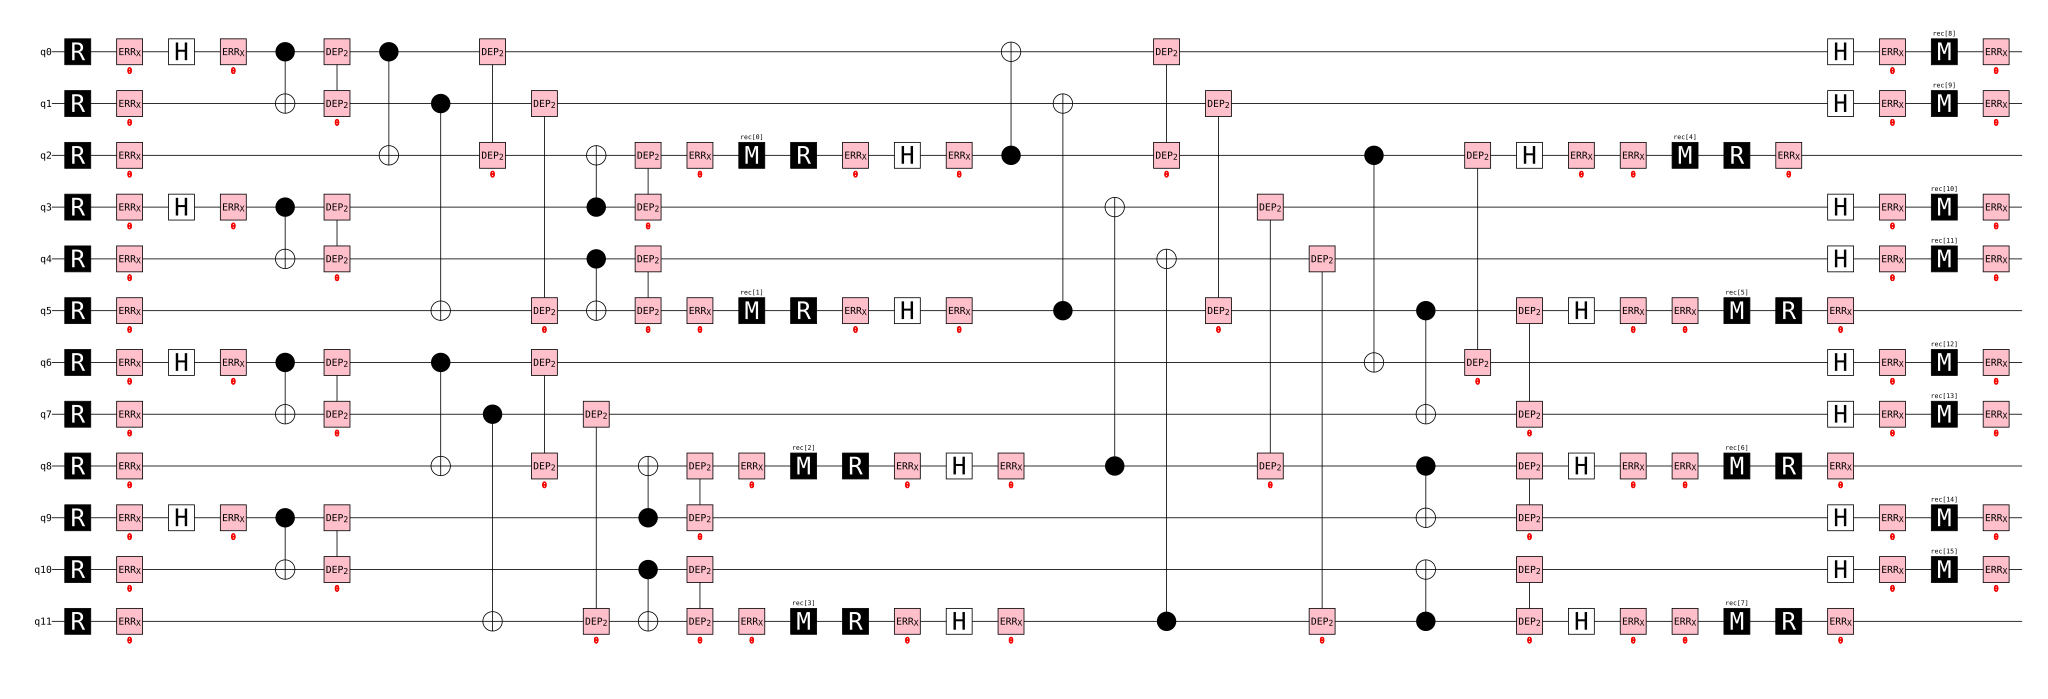

In [11]:
n = 3
i = 4
lstate = "X"
sim_type = "m1"
p_error = 0
shots = int(1e4)
seed = 1

N = 2**(n)
ancilla_qubits = 2**(n - 1)
total_qubits = N + ancilla_qubits

polar_n3 = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, None, None, None, ["x", "z", "x"], total_qubits, 0)
polar_n3.diagram("timeline-svg")



qiskit_runtime_service._discover_account:WARNING:2025-10-24 18:28:18,241: Loading account with the given token. A saved account will not be used.


ibm_torino 6213826 [32, 29, 33, 31, 30, 36, 51, 50, 37, 52, 49, 48]


/Users/handy/Github/quantum_platform/wrappers/stim_wrapper/stim_wrapper.py:732: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


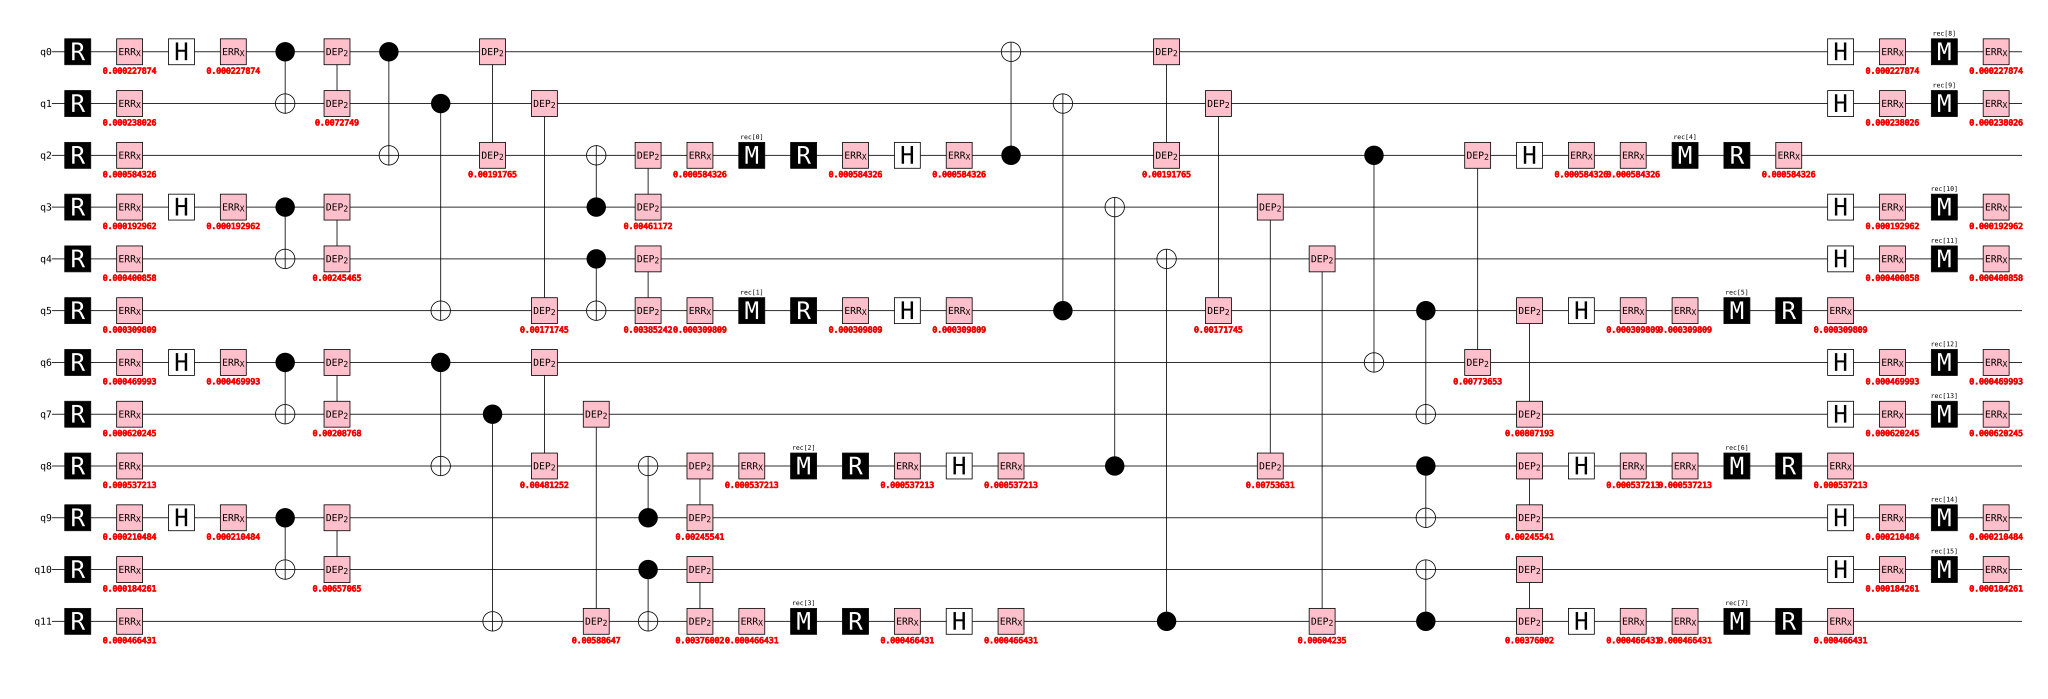

In [12]:
token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")
hw_name = "ibm_torino"
seed_transpiler = random.randint(1, 9999999)

n = 3
i = 2
lstate = "X"
p_error = 1
shots = int(1e5)
seed = 2

backend = service.backend(hw_name)
qc = generate_qiskit_polar_code(n, lstate, sim_type, i)
tqc = compiled_to_qiskit_hardware(qc, backend, 3, seed_transpiler)
initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)
print(hw_name, seed_transpiler, initial_layout)

t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)
cm = backend.coupling_map

polar_n3 = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, error_1q, readout_error, error_2q, ["x", "z", "x"], total_qubits, 0, 
                                            cm = cm, initial_layout = initial_layout)
polar_n3.diagram("timeline-svg")

In [13]:
# function to simulate has been moved to stim_wrapper.py

#### Uniform error rate

In [14]:
n = 4
i = 2
lstate = "X"
p_error = 0.01
shots = int(1e3)
seed = 2

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

sim_type = "normal"
counts = simulate_stim_polar_code_normal(n, lstate, sim_type, i, p_error, shots, seed, backend = None, initial_layout = None)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

sim_type = "m1"
counts = simulate_stim_polar_code_normal(n, lstate, sim_type, i, p_error, shots, seed, backend = None, initial_layout = None)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)


254 0.254 0.0 0 0
316 0.316 0.0 0 0


In [23]:
n = 3
i = 7
lstate = "Z"
sim_type = "m1"
p_error = 0.01
shots = int(1e6)
seed = random.randint(1, 9999999)

simulate_batch_and_save_result_polar_normal(n, lstate, sim_type, p_error, i, shots, seed)

3 Z m1 0.01 7 1000000


In [24]:
calculate_logical_error_result_polar_normal(n, lstate, i, p_error, sim_type)

TypeError: Incorrect number of entries in input argument 'meas'

#### Non-uniform error rate

In [ ]:
token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")
hw_name = "ibm_torino"
backend = service.backend(hw_name)

qiskit_runtime_service._discover_account:WARNING:2025-10-24 18:24:48,666: Loading account with the given token. A saved account will not be used.


In [ ]:
# t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)

# sim_ideal = AerSimulator()
# sim_noisy = AerSimulator.from_backend(backend)

# noise_model = NoiseModel.from_backend(backend)
# noise_model.add_basis_gates("cx")
# for key, value in error_2q.items():
#     dep_error_2q = depolarizing_error(value, 2)
#     noise_model.add_quantum_error(dep_error_2q, "cx", key )

# noise_model.add_basis_gates("h")
# for key, value in error_1q.items():
#     dep_error_1q = depolarizing_error(value, 1)
#     noise_model.add_quantum_error(dep_error_1q, "h", (key,) )

# properties = backend.properties()
# prop_dict = properties.to_dict()
# new_prop_dict = properties.to_dict().copy()

# for i in prop_dict["gates"]:
#     if(i["gate"] == "cz"):
#         gate_dict = copy.deepcopy(i)
#         gate_dict["gate"] = "cx"

#         new_prop_dict["gates"].append(gate_dict)
        
#     if(i["gate"] == "x"):
#         gate_dict = copy.deepcopy(i)
#         gate_dict["gate"] = "h"

#         new_prop_dict["gates"].append(gate_dict)

# new_prop = properties.from_dict(new_prop_dict)

# sim_noisy_cx = AerSimulator(# configuration=backend.configuration(),
#                             properties=new_prop,
#                             # properties=backend.properties(),
#                             noise_model=noise_model)

In [ ]:
# hw_name = "ibm_torino"
# seed_transpiler = random.randint(1, 9999999)
# # seed_transpiler = 12345

# n = 3
# i = 2
# lstate = "X"
# p_error = 0.01
# shots = int(1e4)
# seed = 2
# sim_type = "m1"

# backend = service.backend(hw_name)
# qc = generate_qiskit_polar_code(n, lstate.lower(), sim_type, i)
# tqc = compiled_to_qiskit_hardware(qc, backend, 3, seed_transpiler)
# tqc.draw(fold=-1, idle_wires=False)

In [ ]:
# qc.draw("mpl", fold=-1)

##### Converting from Qiskit Layout to STIM

In [ ]:
# circuit, m_order = compile_circuit_qiskit_to_stim(tqc, backend, 0.1)
# print(m_order)
# circuit.diagram("timeline-svg")

In [ ]:
# # print(m_order)
# sampler = circuit.compile_sampler(seed=1)
# results = sampler.sample(shots=int(1e5) )

# res_bit_string = {}
# for res in results:
#     bit_string = ""
#     for i in res:
#         if i:
#             bit_string = bit_string + "1" 
#         else:
#             bit_string = bit_string + "0"

#     # Create a new list to hold the reordered bits
#     # Initialize it with placeholders (e.g., empty strings)
#     new_bits = [''] * len(bit_string)

#     # Loop through each bit in the original string
#     for i in range(len(bit_string)):
#         # Get the bit from the original string
#         original_bit = bit_string[i]
        
#         # Get the new position for this bit from the order list
#         new_position = m_order[i]
        
#         # Place the bit in its new position
#         new_bits[new_position] = original_bit

#     # Join the list of bits back into a single string
#     reordered_string = "".join(new_bits)[::-1]

#     bit_string = bit_string[::-1]

#     # print(f"Original bitstring:  {bit_string}")
#     # print(f"Reordered bitstring: {reordered_string}")

#     if reordered_string in res_bit_string:
#         res_bit_string[reordered_string] = res_bit_string[reordered_string] + 1
#     else:
#         res_bit_string[reordered_string] = 1

# n = 3
# lstate = "X"
# i = 2
# zpos_list = [-1, -1, 1, i-1, 6, 7, 22, 15, 90, 31, 362]
# get_logical_error_on_accepted_states(n, lstate, res_bit_string, zpos_list)


In [ ]:
n = 5
i = 2
lstate = "X"
p_error = 1
shots = int(1e4)
seed = random.randint(1, 9999999)
# seed = 2

hw_name = "ibm_torino"
backend = service.backend(hw_name)

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

sim_type = "normal"
counts = simulate_stim_polar_code_normal_from_qiskit_circuit(n, lstate, sim_type, i, p_error, shots, seed, backend)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

sim_type = "m1"
counts = simulate_stim_polar_code_normal_from_qiskit_circuit(n, lstate, sim_type, i, p_error, shots, seed, backend)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)


5 0.0005 0.0 0 0
30 0.003 0.0 0 0
